# SpaceX Falcon 9 - EDA with Data Visualization

Exploring the cleaned Falcon 9 launch dataset to see which factors relate to a successful first-stage landing, using Matplotlib and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Flight Number vs. Payload Mass, colored by outcome

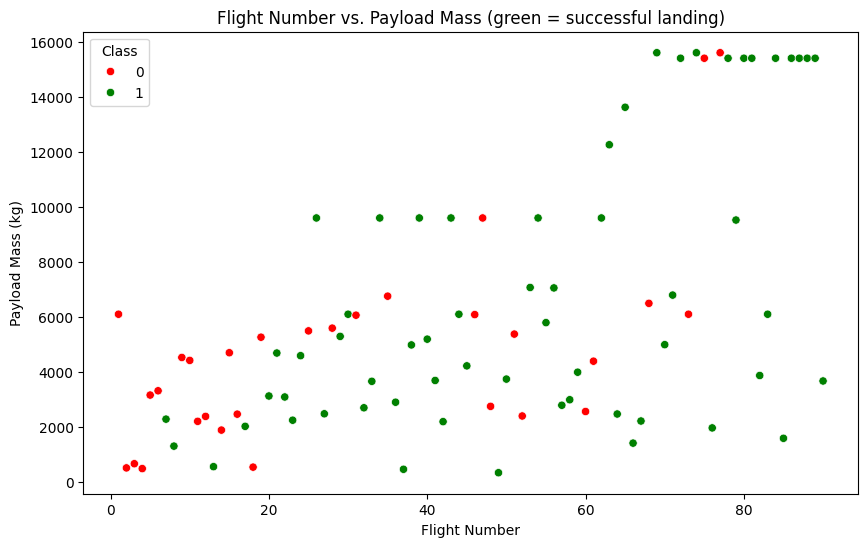

In [2]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='PayloadMass', hue='Class', palette={0: 'red', 1: 'green'})
plt.xlabel('Flight Number')
plt.ylabel('Payload Mass (kg)')
plt.title('Flight Number vs. Payload Mass (green = successful landing)')
plt.show()

Later flights (higher flight numbers) land successfully far more often, regardless of payload mass — SpaceX's landing success rate clearly improved over time as the program matured.

### Flight Number vs. Launch Site

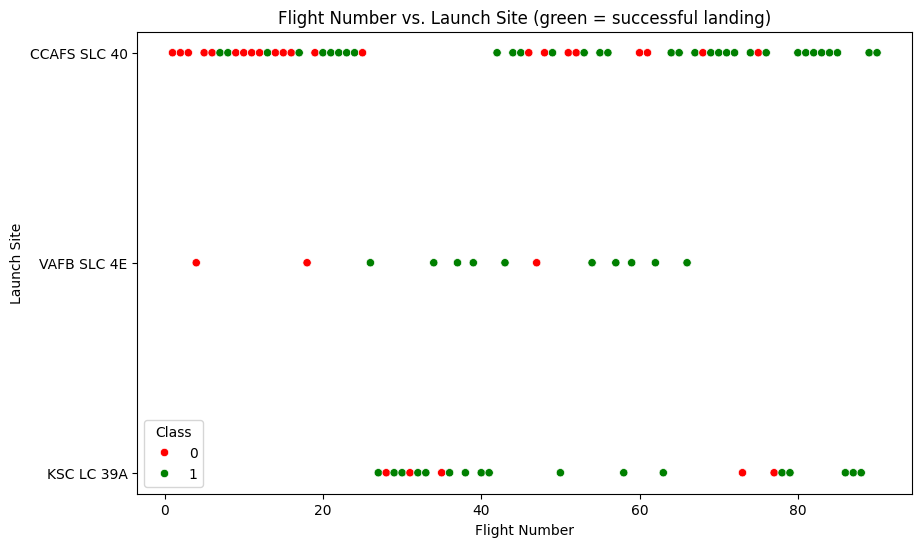

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite', hue='Class', palette={0: 'red', 1: 'green'})
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.title('Flight Number vs. Launch Site (green = successful landing)')
plt.show()

### Payload Mass vs. Launch Site

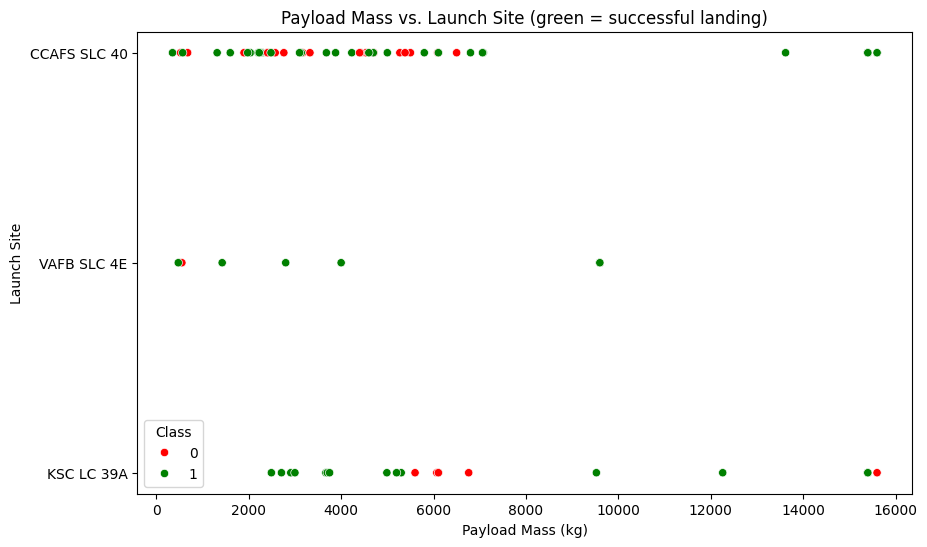

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='LaunchSite', hue='Class', palette={0: 'red', 1: 'green'})
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.title('Payload Mass vs. Launch Site (green = successful landing)')
plt.show()

VAFB SLC 4E has never launched a payload heavier than about 10,000 kg in this dataset, while the Cape Canaveral and KSC sites handle the full range.

### Success rate by Orbit type

/sessions/happy-dreamy-planck/tmp/ipykernel_8/2446884240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orbit_success.index, y=orbit_success.values, palette='viridis')


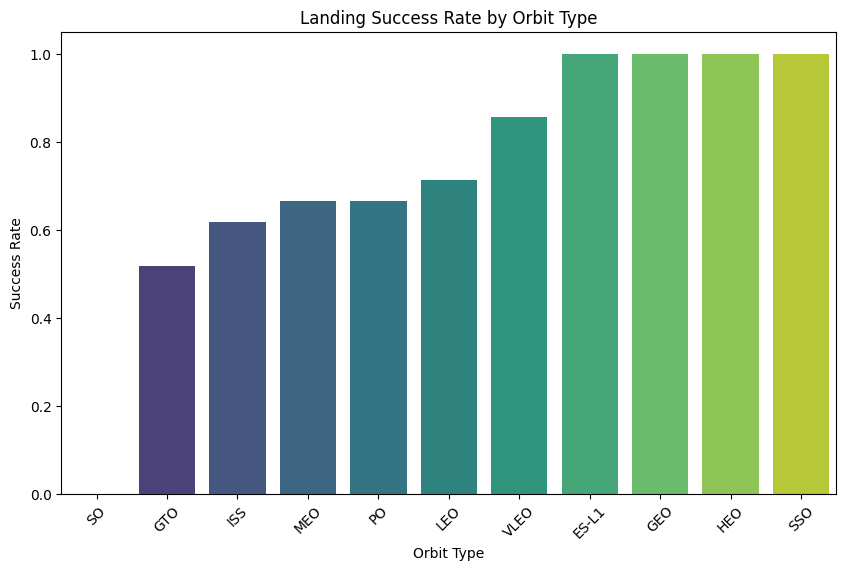

In [5]:
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=orbit_success.index, y=orbit_success.values, palette='viridis')
plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.title('Landing Success Rate by Orbit Type')
plt.xticks(rotation=45)
plt.show()

Orbits like ES-L1, GEO, HEO and SSO show a 100% landing success rate in this data, while SO has a 0% success rate — though it's worth noting some of these orbit types only appear in a handful of flights, so those extremes should be read cautiously.

### Flight Number vs. Orbit type

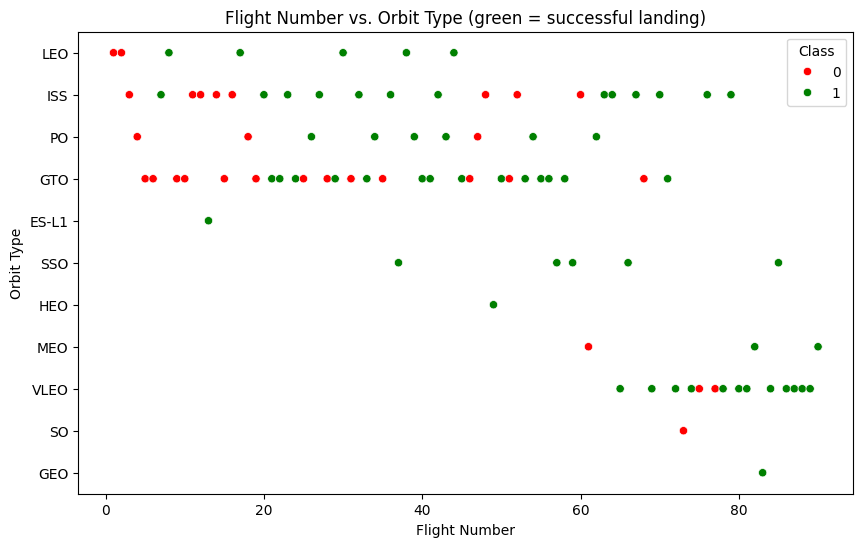

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='Class', palette={0: 'red', 1: 'green'})
plt.xlabel('Flight Number')
plt.ylabel('Orbit Type')
plt.title('Flight Number vs. Orbit Type (green = successful landing)')
plt.show()

### Payload Mass vs. Orbit type

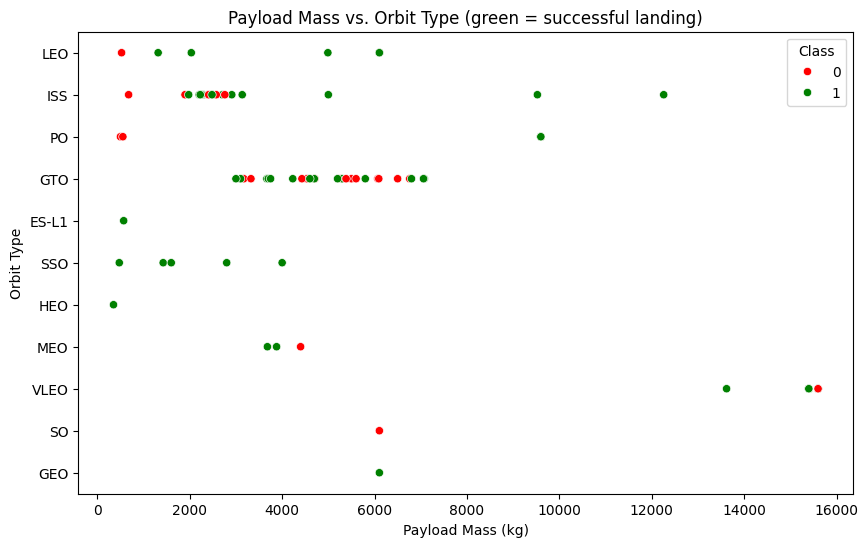

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit', hue='Class', palette={0: 'red', 1: 'green'})
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Orbit Type')
plt.title('Payload Mass vs. Orbit Type (green = successful landing)')
plt.show()

For LEO orbits, success tends to increase with payload mass; for GTO, there isn't an obvious relationship, since both successful and unsuccessful landings appear across the payload range.

### Launch success yearly trend

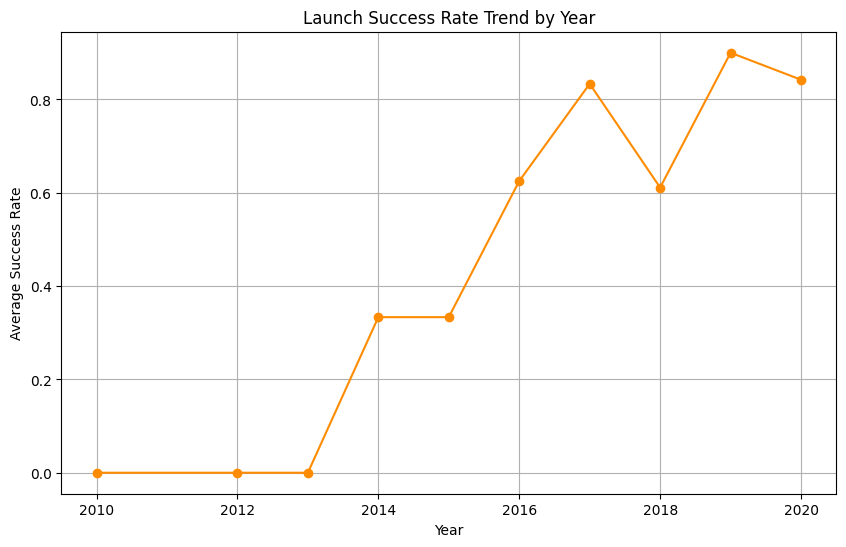

In [8]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['Class'].mean()

plt.figure(figsize=(10, 6))
yearly_success.plot(kind='line', marker='o', color='darkorange')
plt.xlabel('Year')
plt.ylabel('Average Success Rate')
plt.title('Launch Success Rate Trend by Year')
plt.grid(True)
plt.show()

The success rate trends clearly upward from 2013 onward, with a dip around 2015-2016 (early landing experiments) before climbing toward consistently high success rates in later years.

### Feature engineering: one-hot encode categorical columns

In [9]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot = features_one_hot.astype('float64')
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This one-hot encoded feature set is what feeds into the classification models later on.

## Summary

The clearest patterns: landing success improves sharply with flight number (SpaceX got better over time), certain orbit types land far more reliably than others, and launch site plus payload mass interact with orbit type in ways that matter for predicting outcomes. These are exactly the signals the classification models pick up on later.